# NB01 Text Representation (Axis1)

## Member1 (Rui): TF-IDF Unigrams & Bigrams (full data)
 Input: nlp_abstracts_cleaned.csv

 Output: tfidf_unigram_matrix.pkl, tfidf_bigram_matrix.pkl

**Note**: 
This version is based on **entire data**. 
 For neural network models like BERT, 3000+ lines (10% sampled) of data is too little. 

 To facilitate subsequent model training, **the current version processes the full dataset**.

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")

In [3]:
print(f"TOTAL: {len(df)}")
print(df["period"].value_counts().sort_index())

TOTAL: 32221
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [4]:
# text cleaning
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()

    tt = text.split()
    tt = [lemmatizer.lemmatize(w, pos='v') for w in tt]
    tt = [lemmatizer.lemmatize(w, pos='n') for w in tt]
    text = " ".join(tt)

    return text

[nltk_data] Downloading package wordnet to /Users/lr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
from tqdm.auto import tqdm
tqdm.pandas()

# df["abstract_clean"] = df["abstract"].apply(clean_abstract)

df["abstract_clean"] = df["abstract"].progress_apply(clean_abstract)

df = df[df["abstract_clean"].str.len() > 20].copy()
print(f"the Number of Papers after Cleaning: {len(df)}")

  0%|          | 0/32221 [00:00<?, ?it/s]

the Number of Papers after Cleaning: 32221


### Fitting TF-IDF

In [6]:
# sublinear_tf=True  --- use log to take word frequency, compress the weight of high-frequency words
# min_df=5 --- at least appears in 5 papers
# max_df=0.85 ---remove words that appear in more than 85% of the papers
# max_features=20000 --- keep the top 20000 features (words or n-grams) based on term frequency


vectorizer_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)

vectorizer_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)


In [7]:
uni_matrix = vectorizer_uni.fit_transform(df["abstract_clean"])
bi_matrix = vectorizer_bi.fit_transform(df["abstract_clean"])

print(f"the shape of Unigram: {uni_matrix.shape}")
print(f"the shape of Bigram: {bi_matrix.shape}")

the shape of Unigram: (32221, 9464)
the shape of Bigram: (32221, 20000)


In [8]:
# Save for later use
with open("../outputs/tfidf_unigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     uni_matrix,
        "vectorizer": vectorizer_uni,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

with open("../outputs/tfidf_bigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     bi_matrix,
        "vectorizer": vectorizer_bi,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)


### TOP20 keywords

The number of papers varies greatly from period to period (1991-1995 about 448 papers, 2016-2021 about 28405 papers).
If the TF-IDF scores are summed using `.sum()`, the late period has much higher scores than the early period due to the large number of papers, resulting in the curve of all words in the early period being compressed to nearly 0, and the early and late periods are not comparable.
The result is that the curves for all words in the early period are compressed to close to 0, and the early and late periods are not comparable.

The change to `.mean()` when filtering by period can help to calculate the average TF-IDF score of each period.

In [9]:
def top_terms_per_period(matrix, vectorizer, df, period_col="period", top_n=20):
    """
    dict: {period: [(term, score), ...]}
    method: Sum the TF-IDF scores of all papers in each period and take the top_n.
    """
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df[period_col].unique())
    results = {}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten() 
            # use mean to eliminate sample size differences to make word weights comparable across time periods
        top_idx = summed.argsort()[::-1][:top_n]
        results[period] = [(feat[i], round(summed[i], 2)) for i in top_idx]
    return results


print("\nUnigram Top 20 per period ")
uni_top = top_terms_per_period(uni_matrix, vectorizer_uni, df, top_n=20)
for period, terms in uni_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")

print("\nBigram Top 20 per period ")
bi_top = top_terms_per_period(bi_matrix, vectorizer_bi, df, top_n=20)
for period, terms in bi_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")



Unigram Top 20 per period 
1991-1995: grammar, use, base, paper, parse, present, algorithm, language, structure, lexical, parser, word, formalism, corpus, constraint, discourse, process, rule, theory, tag
1996-2000: grammar, use, paper, present, algorithm, language, parse, word, base, corpus, method, speech, structure, information, approach, process, model, rule, set, lexical
2001-2005: language, use, algorithm, paper, word, information, present, base, method, corpus, application, result, text, rule, grammar, model, document, statistical, structure, data
2006-2010: language, word, use, text, present, document, paper, grammar, base, linguistic, structure, information, model, process, approach, corpus, analysis, method, algorithm, mean
2011-2015: word, use, language, base, text, model, method, approach, paper, result, present, feature, sentence, learn, network, data, propose, information, analysis, semantic
2016-2021: model, task, language, train, use, learn, propose, base, data, method

### Vocabulary Comparison

In [10]:
# Vocabulary Comparison Across Periods (Rise VS. Disappearance)
def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words  = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
print(f"\nUnigram emerging words: {sorted(uni_emerged)}")
print(f"Unigram disappearing words: {sorted(uni_disappeared)}")

bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)
print(f"\nBigram emerging words: {sorted(bi_emerged)}")
print(f"Bigram disappearing words: {sorted(bi_disappeared)}")




Unigram emerging words: ['analysis', 'feature', 'learn', 'network', 'neural', 'performance', 'propose', 'semantic', 'sentence', 'state', 'task', 'train']
Unigram disappearing words: ['algorithm', 'application', 'constraint', 'corpus', 'discourse', 'document', 'formalism', 'grammar', 'lexical', 'parse', 'parser', 'process', 'rule', 'set', 'speech', 'statistical', 'structure', 'tag', 'theory']

Bigram emerging words: ['data set', 'deep learn', 'end end', 'et al', 'experimental result', 'fine tune', 'knowledge base', 'large scale', 'neural network', 'paper propose', 'pre train', 'propose method', 'propose novel', 'question answer', 'sentiment analysis', 'social medium', 'social network', 'state art', 'topic model', 'train data', 'word embeddings']
Bigram disappearing words: ['adjoin grammar', 'analogy question', 'anaphora resolution', 'annotation graph', 'base grammar', 'base learn', 'categorial grammar', 'computational linguistics', 'constraint base', 'context free', 'corpus base', 'dis

### Representative vocabulary changes by period

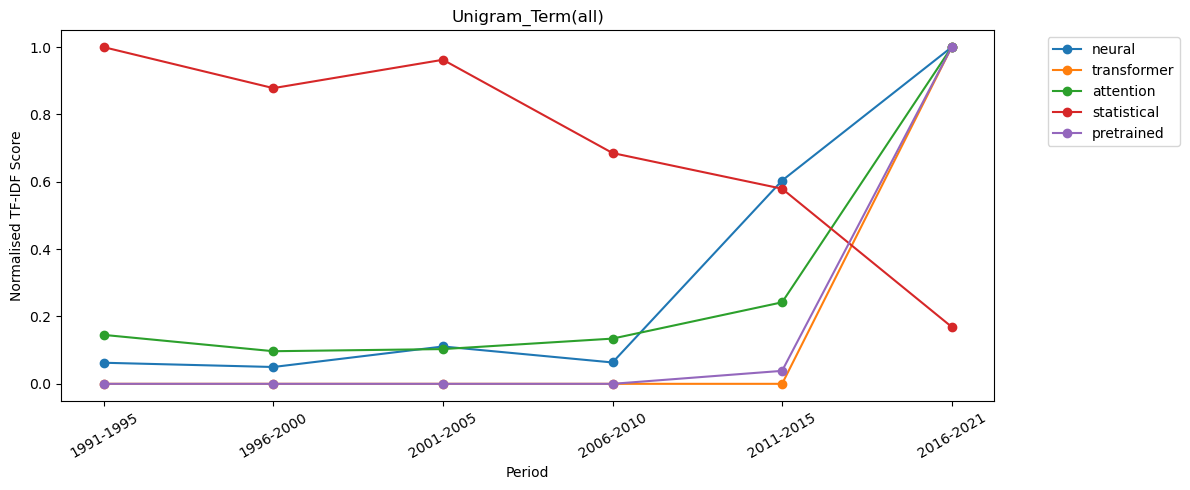

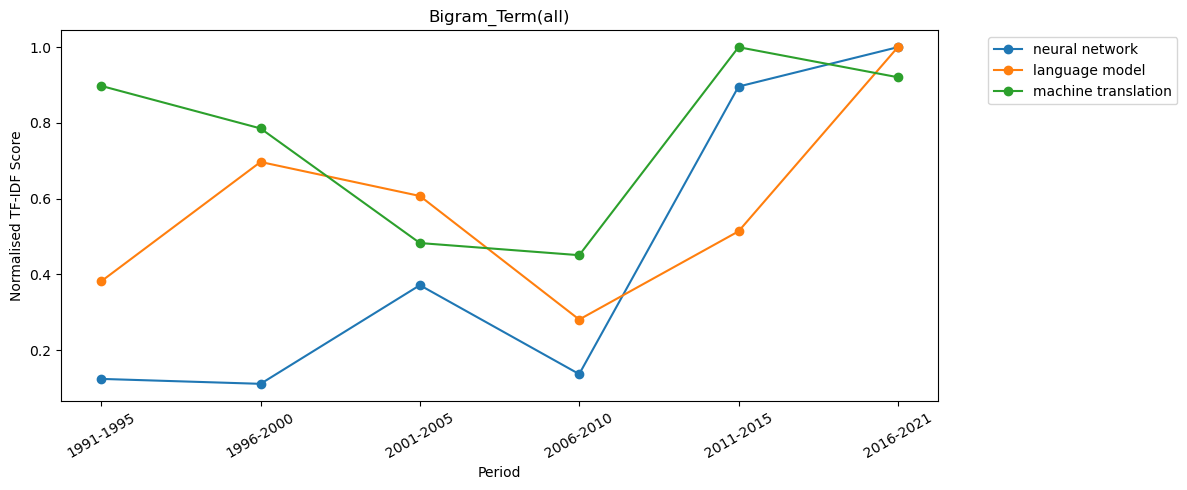

In [11]:
def plot_term_trends(matrix, vectorizer, df, terms, period_col="period", title=""):
    feat  = list(vectorizer.get_feature_names_out())
    periods = sorted(df[period_col].unique())
    valid = [t for t in terms if t in feat]
    if not valid:
        print("None specified terms")
        return

    scores = {t: [] for t in valid}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid:
            scores[t].append(summed[feat.index(t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

unigram_track = ["neural", "transformer", "attention", "parsing", "statistical", "pretrained"]
plot_term_trends(uni_matrix, vectorizer_uni, df, unigram_track, title="Unigram_Term(all)")

bigram_track = ["neural network", "language model", "machine translation",
                "deep learning", "pre trained", "hidden markov"]
plot_term_trends(bi_matrix, vectorizer_bi, df, bigram_track, title="Bigram_Term(all)")



Based on the Unigram and Bigram timelines, we derived three key insights that perfectly illustrate the historic paradigm shift in NLP from the "Statistical Era" to the "Deep Learning Era":

#### 1. The "Death Cross" and Neural Dominance (Unigram)
* **The Exit of Statistical Methods**: The term `statistical`, representing traditional machine learning, dominated from the 1990s to the early 2000s but began an irreversible decline after 2010.
* **The Neural Takeover**: The trajectory of `neural` forms a perfect intersection with `statistical` between 2011 and 2015, marking the exact period when early neural networks began disrupting NLP.
* **The Large Model Explosion**: Most strikingly, `transformer`, `attention`, and `pretrained` were practically non-existent before 2015, but skyrocketed almost vertically between 2016 and 2021. This precisely aligns with the introduction of the Transformer architecture (2017) and pre-trained models like BERT (2018).

#### 2. The Fall of Classic Models and Paradigm Updates (Bigram)
* **The Twilight of Hidden Markov**: `hidden markov` maintained extreme popularity for two decades (1991-2010) as the backbone of sequence labeling. However, post-2010, it suffered a cliff-like drop, being entirely phased out by the deep learning boom.
* **The Rise of Pre-training**: Corresponding with the unigram trends, `language model` and `pre trained` strongly peaked in the last five years, indicating a fundamental shift from "task-specific model design" to the "pre-trained language model + fine-tuning" paradigm.

## Member 2 (Dekai): SBERT Embeddings & LDA Topic Model (full data)
Output: period_labels.pkl,sbert_matrix.pkl,lda_matrix.pkl

In [13]:
# SBERT: encode each abastract into a dense semantic vector.
from sentence_transformers import SentenceTransformer

#gensim tools for topic modelling.
from gensim import corpora
from gensim.models import LdaModel

#Cosine similarity for period-level semantic comparison.
from sklearn.metrics.pairwise import cosine_similarity

### Saving period labels
Saving index, period, and era as a stable reference so that later analyses(cosine distance, PCA, report tables) could stay aligned.

In [14]:
with open("../outputs/period_labels.pkl", "wb") as f:
    pickle.dump({
        "index": df.index,
        "period": df["period"].values,
        "era": df["era"].values,
    }, f)

print("Saved: ../..outputs/period_labels.pkl")

Saved: ../..outputs/period_labels.pkl


### SBERT Embeddings
This section encodes each abstract into a dense semantic vector using a SentenceTransformer model.
The goal is to capture semantic drift across time periods, beyond surface-level vocabulary change.  

#### Peparing data for SBERT
Method(clean_abstract) was designed for TF-IDF. It removes punctuation, numbers, and formatting aggressively. SBERT usually works better with more natural sentence-like input. So it is better to keep the text closer to natural language.

In [15]:
#Make a copy.
df_sbert = df.copy()
#Clean the data.
df_sbert["abstract_sbert"] = df_sbert["abstract"].fillna("").astype(str).str.strip()
#Filter out extremely short texts.
df_sbert = df_sbert[df_sbert["abstract_sbert"].str.len() > 20].copy()

print("Number of paper for SBERT:", len(df_sbert))
df_sbert[["abstract_sbert", "period"]].head()

Number of paper for SBERT: 32221


,abstract_sbert,period
0,In this paper Arabic was investigated from the...,2006-2010
1,In this paper we present the creation of an Ar...,2006-2010
2,"In this paper, we propose an automated evaluat...",2006-2010
3,Intelligent Input Methods (IM) are essential f...,2006-2010
4,This paper includes a reflection on the role o...,2006-2010


#### Loading SBERT model

In [16]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("SBERT model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT model loaded


#### Encoding abstracts with SBERT
The method of model(encode()) could transforms each abstract into an embedding vector.

In [17]:
sbert_matrix = sbert_model.encode(
    df_sbert["abstract_sbert"].tolist(),
    #process 500 abstracts at a time
    batch_size=500,
    #display progress while encoding.
    show_progress_bar=True,
    #return a NumPy array.
    convert_to_numpy=True
)

print("SBERT matrix shape:", sbert_matrix.shape)

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

SBERT matrix shape: (32221, 384)


In [18]:
# Save SBERT matrix
with open("../outputs/sbert_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": sbert_matrix,
        "model_name": "all-MiniLM-L6-v2",
        "index": df_sbert.index,
        "period": df_sbert["period"].values,
        "era": df_sbert["era"].values,
    }, f)

print("Saved: outputs/sbert_matrix.pkl")

Saved: outputs/sbert_matrix.pkl


#### Computing semantic similarity by period

In [19]:
# Get all unique periods and sort them.
periods_sbert = sorted(df_sbert["period"].unique())
# Compute one centroid (average embedding) per period.
period_centroids = []

for period in periods_sbert:
    #Create a boolean mask
    bool_mask = (df_sbert["period"] == period).values
    # Average all document embeddings in this period.
    centroid = sbert_matrix[bool_mask].mean(axis=0)
    period_centroids.append(centroid)

# Stack all centroids into one matrix
period_centroids = np.vstack(period_centroids)

print("Period centroid matrix shape:", period_centroids.shape)

# Compute cosine similarity between period centroids.
semantic_similarity = cosine_similarity(period_centroids)

# Convert to DataFrame.
similarity_df = pd.DataFrame(
    semantic_similarity,
    index=periods_sbert,
    columns=periods_sbert
)

print("Semantic similarity matrix:")
similarity_df
    

Period centroid matrix shape: (6, 384)
Semantic similarity matrix:


,1991-1995,1996-2000,2001-2005,2006-2010,2011-2015,2016-2021
1991-1995,1.000000,0.984785,0.944259,0.933870,0.864053,0.740509
1996-2000,0.984785,1.000000,0.973756,0.948581,0.915566,0.806360
2001-2005,0.944259,0.973756,1.000000,0.970150,0.947571,0.824442
2006-2010,0.933870,0.948581,0.970150,1.000000,0.927628,0.772103
2011-2015,0.864053,0.915566,0.947571,0.927628,1.000000,0.930171
2016-2021,0.740509,0.806360,0.824442,0.772103,0.930171,1.000000


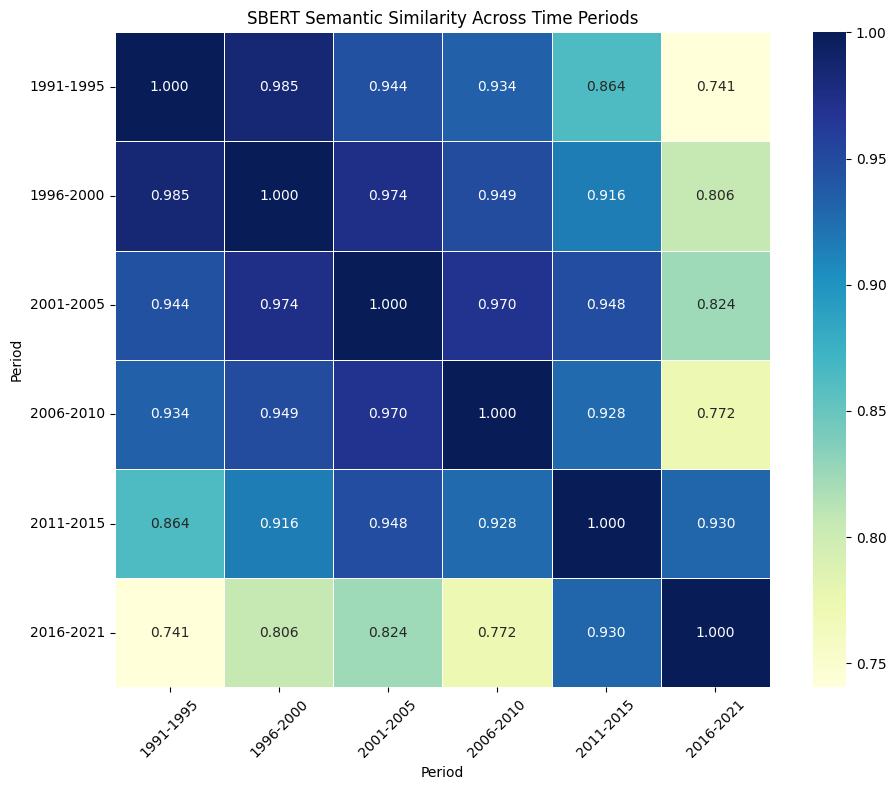

In [20]:
# Draw the heatmap.

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Similarity Across Time Periods(all data)")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The Similarity heatmap shows that periods close in time are more similar, while periods far apart are more different. This means NLP changed gradually, but the long-term change is substantial.

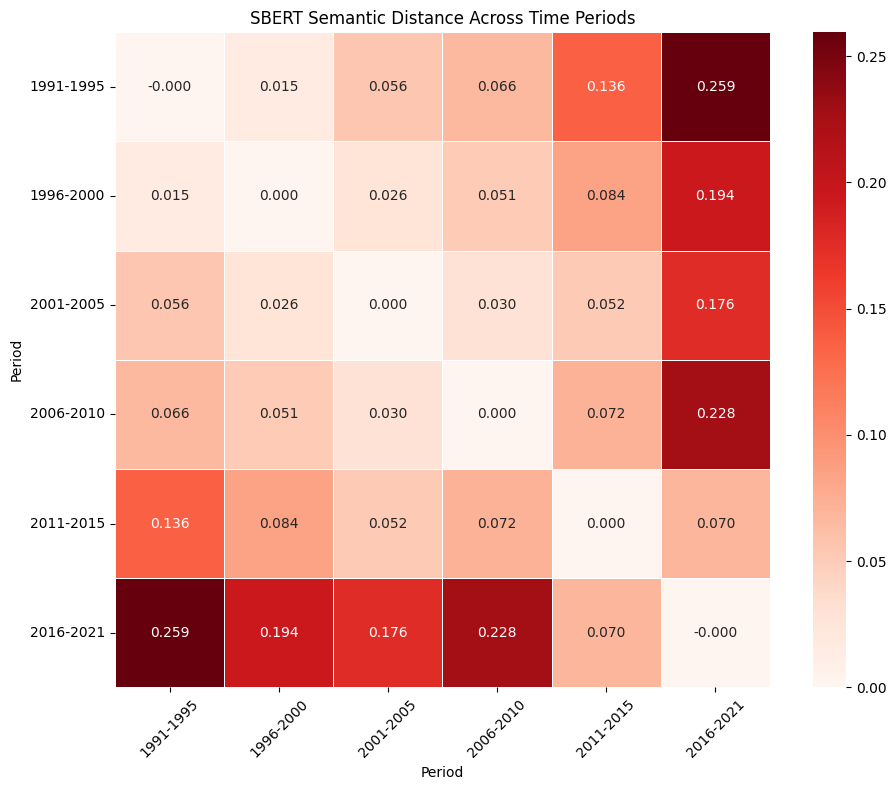

In [21]:
# draw the distance heatmap
distance_df = 1 - similarity_df

plt.figure(figsize=(10, 8))

sns.heatmap(
    distance_df,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Distance Across Time Periods(all data)")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The distance heatmap shows that early NLP and recent NLP are the most different, suggesting that the field’s research focus and way of describing work have changed a lot over time.

### LDA Topic Model
This section models each abstract as a mixture of latent topics.  
The goal is to examine how topic proportions change across historical periods.  

In [22]:
# Make a copy
df_lda = df.copy()

print("Initial number of papers for LDA:", len(df_lda))

Initial number of papers for LDA: 32221


In [23]:
# Cleaning function for LDA
# Clean one abstract and return a token list for LDA.
def clean_for_lda(text):
    if not isinstance(text, str):
        return []
    
    # Lowercase all text.
    text = text.lower()
    
    # Keep only letters and spaces.
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Replace multiple spaces with one space, then strip edges.
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize by spaces.
    tokens = text.split()
    
    # Remove very short tokens.
    tokens = [t for t in tokens if len(t) > 2]
    
    return tokens

In [24]:
# Tokenize abstracts for LDA
df_lda["abstract_lda_tokens"] = df_lda["abstract"].apply(clean_for_lda)

# Remove documents with too few tokens.
df_lda = df_lda[df_lda["abstract_lda_tokens"].map(len) > 5].copy()

print("Number of papers for LDA after filtering:", len(df_lda))
df_lda[["abstract_lda_tokens", "period"]].head()

Number of papers for LDA after filtering: 32219


,abstract_lda_tokens,period
0,"[this, paper, arabic, was, investigated, from,...",2006-2010
1,"[this, paper, present, the, creation, arabic, ...",2006-2010
2,"[this, paper, propose, automated, evaluation, ...",2006-2010
3,"[intelligent, input, methods, are, essential, ...",2006-2010
4,"[this, paper, includes, reflection, the, role,...",2006-2010


In [25]:
# Create a dictionary from all tokenized abstracts.
lda_dictionary = corpora.Dictionary(df_lda["abstract_lda_tokens"])

# Remove extreme words:
# - no_below=5: keep words appearing in at least 5 documents
# - no_above=0.85: remove words appearing in more than 85% of documents
lda_dictionary.filter_extremes(no_below=5, no_above=0.85)

# Convert each document into bag-of-words format.
lda_corpus = [lda_dictionary.doc2bow(tokens) for tokens in df_lda["abstract_lda_tokens"]]

print("Dictionary size", len(lda_dictionary))
print("Corpus size", len(lda_corpus))

Dictionary size 13127
Corpus size 32219


#### Training LDA model
LDA represents each document as a mixture of latent topics.
Each topic is a distribution over words.

In [26]:
num_topics = 10

lda_model = LdaModel(
    corpus=lda_corpus,          
    id2word=lda_dictionary,     
    num_topics=num_topics,  
    # fixed random seed
    random_state=42,
    # number of passes over the corpus
    passes=10, 
    # batch size
    chunksize=1000, 
    # automatically learn alpha
    alpha="auto",               
    per_word_topics=False
)

print("LDA model trained")

LDA model trained


In [27]:
# Check topics
for topic_id in range(num_topics):
    print(f"Topic {topic_id}:")
    print(lda_model.print_topic(topic_id, topn=10))

Topic 0:
0.038*"for" + 0.018*"this" + 0.013*"from" + 0.013*"system" + 0.012*"with" + 0.011*"data" + 0.010*"text" + 0.009*"are" + 0.009*"paper" + 0.008*"corpus"
Topic 1:
0.024*"dialogue" + 0.019*"generation" + 0.016*"attention" + 0.014*"image" + 0.013*"model" + 0.011*"visual" + 0.011*"with" + 0.010*"information" + 0.009*"our" + 0.009*"context"
Topic 2:
0.022*"knowledge" + 0.020*"graph" + 0.018*"semantic" + 0.017*"parsing" + 0.017*"grammar" + 0.015*"relations" + 0.013*"structure" + 0.012*"for" + 0.012*"syntactic" + 0.012*"relation"
Topic 3:
0.032*"that" + 0.019*"this" + 0.018*"are" + 0.016*"language" + 0.011*"for" + 0.010*"have" + 0.010*"these" + 0.009*"can" + 0.009*"their" + 0.009*"has"
Topic 4:
0.027*"word" + 0.018*"words" + 0.016*"for" + 0.015*"that" + 0.014*"are" + 0.012*"method" + 0.011*"based" + 0.010*"this" + 0.010*"embeddings" + 0.009*"information"
Topic 5:
0.025*"models" + 0.024*"model" + 0.021*"that" + 0.017*"for" + 0.015*"with" + 0.013*"our" + 0.012*"training" + 0.012*"this" +

#### Building dense LDA matrix

In [28]:
# Create an empty matrix
lda_matrix = np.zeros((len(lda_corpus), num_topics))

for i, bow in enumerate(lda_corpus):
    # Get topic probabilities for one document.
    doc_topics = lda_model.get_document_topics(bow, minimum_probability=0)
    
    # Fill the dense matrix.
    for topic_id, prob in doc_topics:
        lda_matrix[i, topic_id] = prob

print("LDA matrix shape:", lda_matrix.shape)

LDA matrix shape: (32219, 10)


In [29]:
#save LDA matrix
with open("../outputs/lda_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": lda_matrix,
        "num_topics": num_topics,
        "dictionary": lda_dictionary,
        "index": df_lda.index,
        "period": df_lda["period"].values,
        "era": df_lda["era"].values,
    }, f)

print("Saved: ../outputs/lda_matrix.pkl")

Saved: ../outputs/lda_matrix.pkl


#### Computing topic proportions per period

In [30]:
# Get sorted period labels.
periods_lda = sorted(df_lda["period"].unique())

# Store the average topic distribution for each period.
topic_by_period = []

for period in periods_lda:
    bool_mask = (df_lda["period"] == period).values
    
    topic_mean = lda_matrix[bool_mask].mean(axis=0)
    topic_by_period.append(topic_mean)

# Convert to a 2D array.
topic_by_period = np.vstack(topic_by_period)

# Convert to DataFrame.
topic_period_df = pd.DataFrame(
    topic_by_period,
    index=periods_lda,
    columns=[f"Topic_{i}" for i in range(num_topics)]
)

print("Topic proportions per period:")
topic_period_df

Topic proportions per period:


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
1991-1995,0.193078,0.033119,0.184834,0.219552,0.143615,0.147916,0.031853,0.024712,0.007019,0.014303
1996-2000,0.199907,0.028591,0.138835,0.195515,0.181338,0.172467,0.025101,0.030895,0.010584,0.016764
2001-2005,0.233933,0.030222,0.093269,0.203038,0.177656,0.153984,0.028837,0.025878,0.021389,0.031793
2006-2010,0.216669,0.025036,0.093156,0.263440,0.168890,0.139302,0.030817,0.018681,0.022260,0.021750
2011-2015,0.182874,0.036234,0.059954,0.200592,0.180918,0.203028,0.034585,0.023510,0.052176,0.026129
2016-2021,0.143103,0.063473,0.035573,0.148055,0.111274,0.333788,0.041737,0.026874,0.048810,0.047311


In [31]:
#show top topics by period
for period in periods_lda:
    print(f"Top topics for {period}:")
    print(topic_period_df.loc[period].sort_values(ascending=False).head(3))

Top topics for 1991-1995:
Topic_3    0.219552
Topic_0    0.193078
Topic_2    0.184834
Name: 1991-1995, dtype: float64
Top topics for 1996-2000:
Topic_0    0.199907
Topic_3    0.195515
Topic_4    0.181338
Name: 1996-2000, dtype: float64
Top topics for 2001-2005:
Topic_0    0.233933
Topic_3    0.203038
Topic_4    0.177656
Name: 2001-2005, dtype: float64
Top topics for 2006-2010:
Topic_3    0.263440
Topic_0    0.216669
Topic_4    0.168890
Name: 2006-2010, dtype: float64
Top topics for 2011-2015:
Topic_5    0.203028
Topic_3    0.200592
Topic_0    0.182874
Name: 2011-2015, dtype: float64
Top topics for 2016-2021:
Topic_5    0.333788
Topic_3    0.148055
Topic_0    0.143103
Name: 2016-2021, dtype: float64


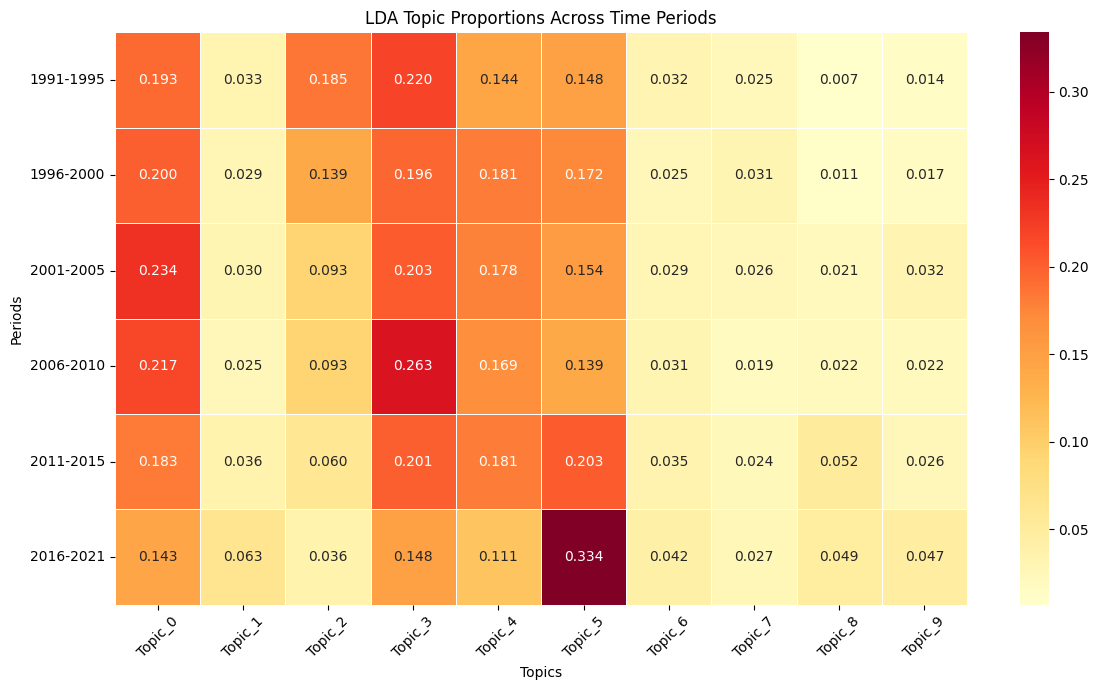

In [32]:
# Draw heatmap of topic proportions by period.
plt.figure(figsize=(12, 7))

sns.heatmap(
    topic_period_df,
    annot=True,        
    fmt=".3f",           
    cmap="YlOrRd",       
    linewidths=0.5
)

plt.title("LDA Topic Proportions Across Time Periods(all data)")
plt.xlabel("Topics")
plt.ylabel("Periods")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

This heatmap is useful for showing:
- Topic_5 becomes much stronger in the latest period
- Topic_2 steadily weakens over time
- Topic_0 and Topic_3 are stronger in earlier and middle periods
- the dominant thematic structure changes across time

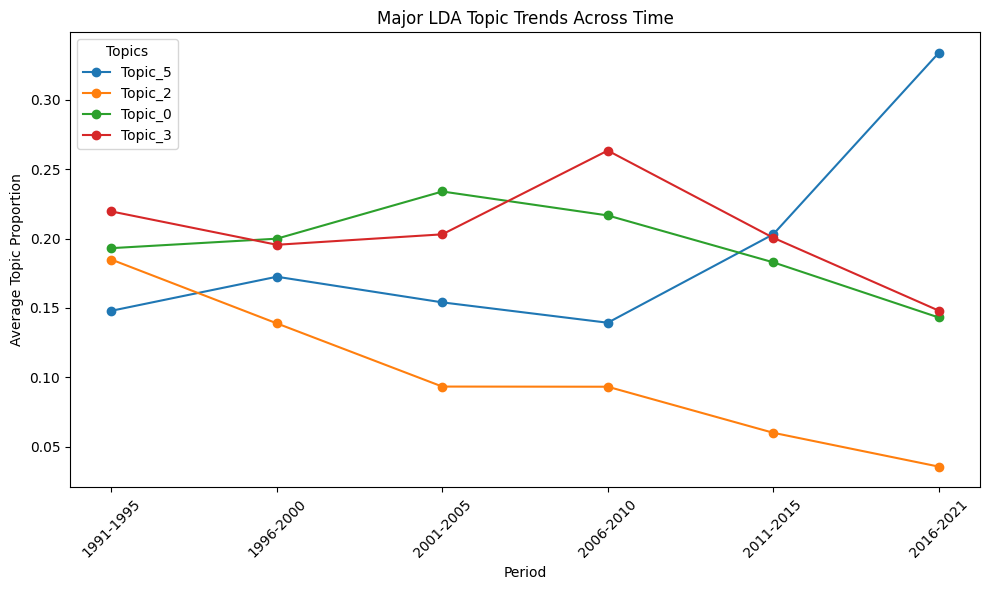

In [33]:
# Select the topics which need to track.
selected_topics = ["Topic_5", "Topic_2", "Topic_0", "Topic_3"]

plt.figure(figsize=(10, 6))

for topic in selected_topics:
    plt.plot(
        topic_period_df.index,
        topic_period_df[topic],
        marker="o",
        label=topic
    )

plt.title("Major LDA Topic Trends Across Time(all data)")
plt.xlabel("Period")
plt.ylabel("Average Topic Proportion")

plt.xticks(rotation=45)
plt.legend(title="Topics")
plt.tight_layout()
plt.show()

This plot is especially good for showing trend stories:

- Topic_5 rises sharply in recent periods
- Topic_2 declines over the long term
- Topic_0 peaks earlier and then falls
- Topic_3 remains relatively stable, but is overtaken by Topic_5 later